In [15]:
import pandas as pd

# 데이터 로드
residual1 = pd.read_csv('data/residual_features_frac_0.1.csv')
residual2 = pd.read_csv('data/residual_features_frac_0.2.csv')
residual3 = pd.read_csv('data/residual_features_frac_0.3.csv')
residual4 = pd.read_csv('data/residual_features_frac_0.4.csv')
residual5 = pd.read_csv('data/residual_features_frac_0.5.csv')
residual6 = pd.read_csv('data/residual_features_frac_0.6.csv')

mode_residual1 = pd.read_csv('data/mode_selected/residual_features_frac_0.1.csv')
mode_residual2 = pd.read_csv('data/mode_selected/residual_features_frac_0.2.csv')
mode_residual3 = pd.read_csv('data/mode_selected/residual_features_frac_0.3.csv')
mode_residual4 = pd.read_csv('data/mode_selected/residual_features_frac_0.4.csv')
mode_residual5 = pd.read_csv('data/mode_selected/residual_features_frac_0.5.csv')
mode_residual6 = pd.read_csv('data/mode_selected/residual_features_frac_0.6.csv')

# datasets 딕셔너리 생성
datasets = {
    0.1: residual1.copy(),
    0.2: residual2.copy(),
    0.3: residual3.copy()
}

# 정보 확인
print("residual1 info")
residual1.info()
print("\n" + "="*50 + "\n")

print("residual2 info")
residual2.info()
print("\n" + "="*50 + "\n")

print("residual3 info")
residual3.info()

residual1 info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   sample_idx  400 non-null    int64  
 1   0           365 non-null    float64
 2   1           356 non-null    float64
 3   2           357 non-null    float64
 4   3           366 non-null    float64
 5   4           369 non-null    float64
 6   5           347 non-null    float64
 7   status      400 non-null    object 
dtypes: float64(6), int64(1), object(1)
memory usage: 25.1+ KB


residual2 info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   sample_idx  400 non-null    int64  
 1   0           316 non-null    float64
 2   1           319 non-null    float64
 3   2           311 non-null    float64
 4   3           325 non-null    float64


In [16]:
from pct import PCTChart

# --------------------------------------------------
# 1) Use preloaded dataframe: residual1
# --------------------------------------------------
df = residual1.copy()

# feature columns: exclude index/status columns
feature_cols = [c for c in df.columns if c not in ["sample_idx", "status"]]

X = df[feature_cols].copy()
y = df["status"].copy()

# numeric conversion
X = X.apply(pd.to_numeric, errors="coerce")

# --------------------------------------------------
# 2) Split
# --------------------------------------------------
train_mask = df["sample_idx"].between(0, 199)
normal_mask = df["sample_idx"].between(200, 319)
damaged_mask = df["sample_idx"].between(320, 399)

X_train = X.loc[train_mask].to_numpy(dtype=float)
X_normal = X.loc[normal_mask].to_numpy(dtype=float)
X_damaged = X.loc[damaged_mask].to_numpy(dtype=float)

y_normal = y.loc[normal_mask].to_numpy()
y_damaged = y.loc[damaged_mask].to_numpy()

# --------------------------------------------------
# 3) Fit PCT
# --------------------------------------------------
pct = PCTChart(alpha=0.05)
pct.fit(X_train)

# --------------------------------------------------
# 4) Score
# --------------------------------------------------
res_normal = pct.score_samples(X_normal)
res_damaged = pct.score_samples(X_damaged)

normal_alarm = res_normal.alarms
damaged_alarm = res_damaged.alarms

far = normal_alarm.mean()
detection_rate = damaged_alarm.mean()

# --------------------------------------------------
# 5) Summary
# --------------------------------------------------
print("=" * 70)
print("PCT Evaluation Summary")
print("=" * 70)
print(f"# train samples         : {len(X_train)}")
print(f"# unseen normal samples : {len(X_normal)}")
print(f"# damaged samples       : {len(X_damaged)}")
print("-" * 70)
print(f"False Alarm Rate (200~319) : {far:.4f} ({normal_alarm.sum()}/{len(normal_alarm)})")
print(f"Detection Rate  (320~399) : {detection_rate:.4f} ({damaged_alarm.sum()}/{len(damaged_alarm)})")
print("=" * 70)

# --------------------------------------------------
# 6) Detailed result table
# --------------------------------------------------
result_normal = pd.DataFrame({
    "sample_idx": df.loc[normal_mask, "sample_idx"].values,
    "status": y_normal,
    "Q_star": res_normal.q_values,
    "UCL": res_normal.ucls,
    "alarm": res_normal.alarms,
    "n_obs_vars": res_normal.n_obs_vars,
    "df": res_normal.dfs,
    "scale": res_normal.scales,
})

result_damaged = pd.DataFrame({
    "sample_idx": df.loc[damaged_mask, "sample_idx"].values,
    "status": y_damaged,
    "Q_star": res_damaged.q_values,
    "UCL": res_damaged.ucls,
    "alarm": res_damaged.alarms,
    "n_obs_vars": res_damaged.n_obs_vars,
    "df": res_damaged.dfs,
    "scale": res_damaged.scales,
})

result_all = pd.concat([result_normal, result_damaged], axis=0, ignore_index=True)

# --------------------------------------------------
# 7) Confusion summary
# --------------------------------------------------
tp = int(damaged_alarm.sum())
fn = int((~damaged_alarm).sum())
fp = int(normal_alarm.sum())
tn = int((~normal_alarm).sum())

print("\nConfusion-like summary")
print("-" * 70)
print(f"TN (normal -> normal) : {tn}")
print(f"FP (normal -> alarm)  : {fp}")
print(f"FN (damage -> normal) : {fn}")
print(f"TP (damage -> alarm)  : {tp}")

# 필요하면 저장
# result_all.to_csv("pct_results_frac_0.1.csv", index=False)


PCT Evaluation Summary
# train samples         : 200
# unseen normal samples : 120
# damaged samples       : 80
----------------------------------------------------------------------
False Alarm Rate (200~319) : 0.0500 (6/120)
Detection Rate  (320~399) : 1.0000 (80/80)

Confusion-like summary
----------------------------------------------------------------------
TN (normal -> normal) : 114
FP (normal -> alarm)  : 6
FN (damage -> normal) : 0
TP (damage -> alarm)  : 80


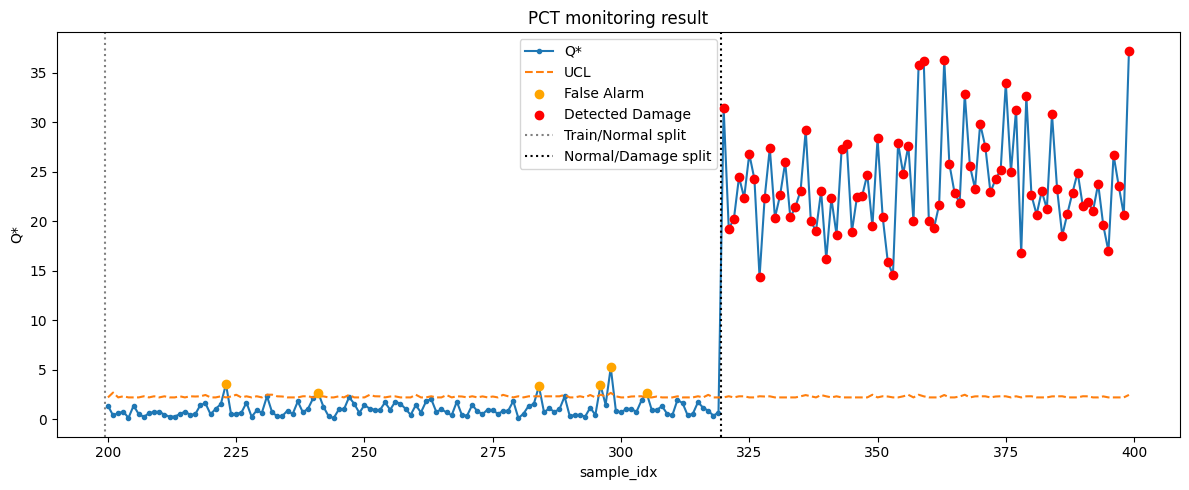

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(result_all["sample_idx"], result_all["Q_star"], label="Q*", marker="o", ms=3)
plt.plot(result_all["sample_idx"], result_all["UCL"], label="UCL", linestyle="--")

false_alarm_pts = result_all[(result_all["status"] == "Normal") & (result_all["alarm"] == True)]
detected_damage_pts = result_all[(result_all["status"] == "Damaged") & (result_all["alarm"] == True)]

plt.scatter(false_alarm_pts["sample_idx"], false_alarm_pts["Q_star"],
            color="orange", label="False Alarm", zorder=3)

plt.scatter(detected_damage_pts["sample_idx"], detected_damage_pts["Q_star"],
            color="red", label="Detected Damage", zorder=3)

plt.axvline(199.5, color="gray", linestyle=":", label="Train/Normal split")
plt.axvline(319.5, color="black", linestyle=":", label="Normal/Damage split")

plt.xlabel("sample_idx")
plt.ylabel("Q*")
plt.title("PCT monitoring result")
plt.legend()
plt.tight_layout()
plt.show()


In [42]:
# --------------------------------------------------
# 1) Use preloaded dataframe: residual2
# --------------------------------------------------
df = residual2.copy()

# feature columns: exclude index/status columns
feature_cols = ['0', '2', '3', '4']

X = df[feature_cols].copy()
y = df["status"].copy()

# numeric conversion
X = X.apply(pd.to_numeric, errors="coerce")

# --------------------------------------------------
# 2) Split
# --------------------------------------------------
train_mask = df["sample_idx"].between(0, 199)
normal_mask = df["sample_idx"].between(200, 319)
damaged_mask = df["sample_idx"].between(320, 399)

X_train = X.loc[train_mask].to_numpy(dtype=float)
X_normal = X.loc[normal_mask].to_numpy(dtype=float)
X_damaged = X.loc[damaged_mask].to_numpy(dtype=float)

y_normal = y.loc[normal_mask].to_numpy()
y_damaged = y.loc[damaged_mask].to_numpy()

# --------------------------------------------------
# 3) Fit PCT
# --------------------------------------------------
pct = PCTChart(alpha=0.05)
pct.fit(X_train)

# --------------------------------------------------
# 4) Score
# --------------------------------------------------
res_normal = pct.score_samples(X_normal)
res_damaged = pct.score_samples(X_damaged)

normal_alarm = res_normal.alarms
damaged_alarm = res_damaged.alarms

far = normal_alarm.mean()
detection_rate = damaged_alarm.mean()

# --------------------------------------------------
# 5) Summary
# --------------------------------------------------
print("=" * 70)
print("PCT Evaluation Summary")
print("=" * 70)
print(f"# train samples         : {len(X_train)}")
print(f"# unseen normal samples : {len(X_normal)}")
print(f"# damaged samples       : {len(X_damaged)}")
print("-" * 70)
print(f"False Alarm Rate (200~319) : {far:.4f} ({normal_alarm.sum()}/{len(normal_alarm)})")
print(f"Detection Rate  (320~399) : {detection_rate:.4f} ({damaged_alarm.sum()}/{len(damaged_alarm)})")
print("=" * 70)

# --------------------------------------------------
# 6) Detailed result table
# --------------------------------------------------
result_normal = pd.DataFrame({
    "sample_idx": df.loc[normal_mask, "sample_idx"].values,
    "status": y_normal,
    "Q_star": res_normal.q_values,
    "UCL": res_normal.ucls,
    "alarm": res_normal.alarms,
    "n_obs_vars": res_normal.n_obs_vars,
    "df": res_normal.dfs,
    "scale": res_normal.scales,
})

result_damaged = pd.DataFrame({
    "sample_idx": df.loc[damaged_mask, "sample_idx"].values,
    "status": y_damaged,
    "Q_star": res_damaged.q_values,
    "UCL": res_damaged.ucls,
    "alarm": res_damaged.alarms,
    "n_obs_vars": res_damaged.n_obs_vars,
    "df": res_damaged.dfs,
    "scale": res_damaged.scales,
})

result_all = pd.concat([result_normal, result_damaged], axis=0, ignore_index=True)

# --------------------------------------------------
# 7) Confusion summary
# --------------------------------------------------
tp = int(damaged_alarm.sum())
fn = int((~damaged_alarm).sum())
fp = int(normal_alarm.sum())
tn = int((~normal_alarm).sum())

print("\nConfusion-like summary")
print("-" * 70)
print(f"TN (normal -> normal) : {tn}")
print(f"FP (normal -> alarm)  : {fp}")
print(f"FN (damage -> normal) : {fn}")
print(f"TP (damage -> alarm)  : {tp}")

# 필요하면 저장
# result_all.to_csv("pct_results_frac_0.1.csv", index=False)


PCT Evaluation Summary
# train samples         : 200
# unseen normal samples : 120
# damaged samples       : 80
----------------------------------------------------------------------
False Alarm Rate (200~319) : 0.0833 (10/120)
Detection Rate  (320~399) : 1.0000 (80/80)

Confusion-like summary
----------------------------------------------------------------------
TN (normal -> normal) : 110
FP (normal -> alarm)  : 10
FN (damage -> normal) : 0
TP (damage -> alarm)  : 80


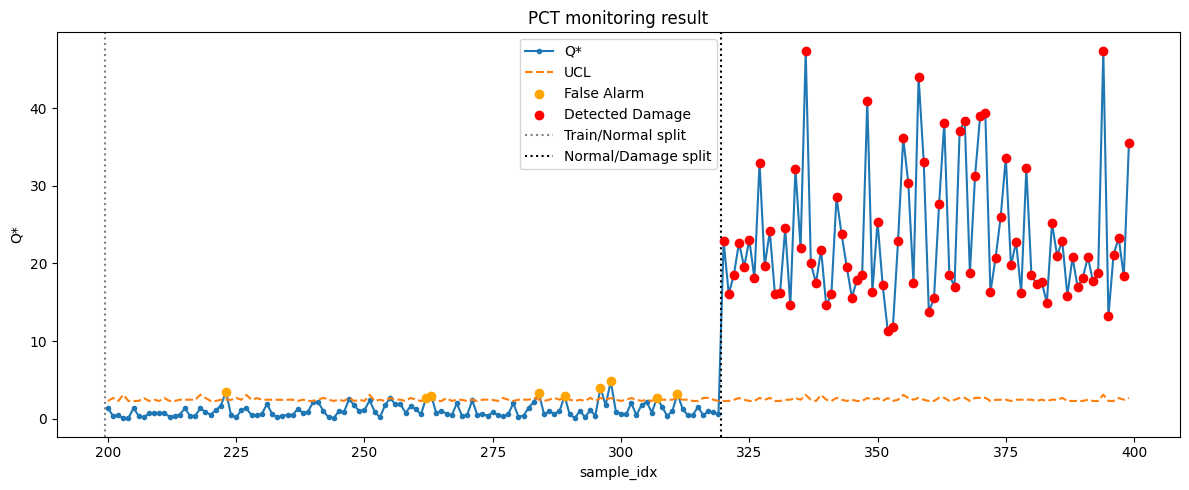

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(result_all["sample_idx"], result_all["Q_star"], label="Q*", marker="o", ms=3)
plt.plot(result_all["sample_idx"], result_all["UCL"], label="UCL", linestyle="--")

false_alarm_pts = result_all[(result_all["status"] == "Normal") & (result_all["alarm"] == True)]
detected_damage_pts = result_all[(result_all["status"] == "Damaged") & (result_all["alarm"] == True)]

plt.scatter(false_alarm_pts["sample_idx"], false_alarm_pts["Q_star"],
            color="orange", label="False Alarm", zorder=3)

plt.scatter(detected_damage_pts["sample_idx"], detected_damage_pts["Q_star"],
            color="red", label="Detected Damage", zorder=3)

plt.axvline(199.5, color="gray", linestyle=":", label="Train/Normal split")
plt.axvline(319.5, color="black", linestyle=":", label="Normal/Damage split")

plt.xlabel("sample_idx")
plt.ylabel("Q*")
plt.title("PCT monitoring result")
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
from pct import PCTChart

# --------------------------------------------------
# 1) Use preloaded dataframe: residual3
# --------------------------------------------------
df = residual3.copy()

# feature columns: exclude index/status columns
feature_cols = ['0', '2', '3', '4']

X = df[feature_cols].copy()
y = df["status"].copy()

# numeric conversion
X = X.apply(pd.to_numeric, errors="coerce")

# --------------------------------------------------
# 2) Split
# --------------------------------------------------
train_mask = df["sample_idx"].between(0, 199)
normal_mask = df["sample_idx"].between(200, 319)
damaged_mask = df["sample_idx"].between(320, 399)

X_train = X.loc[train_mask].to_numpy(dtype=float)
X_normal = X.loc[normal_mask].to_numpy(dtype=float)
X_damaged = X.loc[damaged_mask].to_numpy(dtype=float)

y_normal = y.loc[normal_mask].to_numpy()
y_damaged = y.loc[damaged_mask].to_numpy()

# --------------------------------------------------
# 3) Fit PCT
# --------------------------------------------------
pct = PCTChart(alpha=0.05)
pct.fit(X_train)

# --------------------------------------------------
# 4) Score
# --------------------------------------------------
res_normal = pct.score_samples(X_normal)
res_damaged = pct.score_samples(X_damaged)

normal_alarm = res_normal.alarms
damaged_alarm = res_damaged.alarms

far = normal_alarm.mean()
detection_rate = damaged_alarm.mean()

# --------------------------------------------------
# 5) Summary
# --------------------------------------------------
print("=" * 70)
print("PCT Evaluation Summary")
print("=" * 70)
print(f"# train samples         : {len(X_train)}")
print(f"# unseen normal samples : {len(X_normal)}")
print(f"# damaged samples       : {len(X_damaged)}")
print("-" * 70)
print(f"False Alarm Rate (200~319) : {far:.4f} ({normal_alarm.sum()}/{len(normal_alarm)})")
print(f"Detection Rate  (320~399) : {detection_rate:.4f} ({damaged_alarm.sum()}/{len(damaged_alarm)})")
print("=" * 70)

# --------------------------------------------------
# 6) Detailed result table
# --------------------------------------------------
result_normal = pd.DataFrame({
    "sample_idx": df.loc[normal_mask, "sample_idx"].values,
    "status": y_normal,
    "Q_star": res_normal.q_values,
    "UCL": res_normal.ucls,
    "alarm": res_normal.alarms,
    "n_obs_vars": res_normal.n_obs_vars,
    "df": res_normal.dfs,
    "scale": res_normal.scales,
})

result_damaged = pd.DataFrame({
    "sample_idx": df.loc[damaged_mask, "sample_idx"].values,
    "status": y_damaged,
    "Q_star": res_damaged.q_values,
    "UCL": res_damaged.ucls,
    "alarm": res_damaged.alarms,
    "n_obs_vars": res_damaged.n_obs_vars,
    "df": res_damaged.dfs,
    "scale": res_damaged.scales,
})

result_all = pd.concat([result_normal, result_damaged], axis=0, ignore_index=True)

# --------------------------------------------------
# 7) Confusion summary
# --------------------------------------------------
tp = int(damaged_alarm.sum())
fn = int((~damaged_alarm).sum())
fp = int(normal_alarm.sum())
tn = int((~normal_alarm).sum())

print("\nConfusion-like summary")
print("-" * 70)
print(f"TN (normal -> normal) : {tn}")
print(f"FP (normal -> alarm)  : {fp}")
print(f"FN (damage -> normal) : {fn}")
print(f"TP (damage -> alarm)  : {tp}")

# 필요하면 저장
# result_all.to_csv("pct_results_frac_0.1.csv", index=False)


PCT Evaluation Summary
# train samples         : 200
# unseen normal samples : 120
# damaged samples       : 80
----------------------------------------------------------------------
False Alarm Rate (200~319) : 0.0917 (11/120)
Detection Rate  (320~399) : 1.0000 (80/80)

Confusion-like summary
----------------------------------------------------------------------
TN (normal -> normal) : 109
FP (normal -> alarm)  : 11
FN (damage -> normal) : 0
TP (damage -> alarm)  : 80


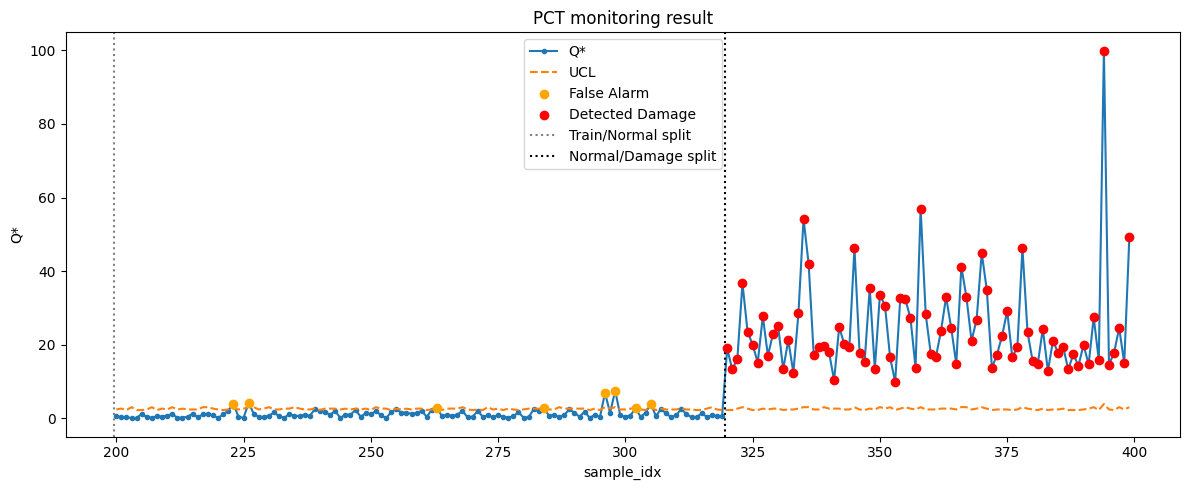

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(result_all["sample_idx"], result_all["Q_star"], label="Q*", marker="o", ms=3)
plt.plot(result_all["sample_idx"], result_all["UCL"], label="UCL", linestyle="--")

false_alarm_pts = result_all[(result_all["status"] == "Normal") & (result_all["alarm"] == True)]
detected_damage_pts = result_all[(result_all["status"] == "Damaged") & (result_all["alarm"] == True)]

plt.scatter(false_alarm_pts["sample_idx"], false_alarm_pts["Q_star"],
            color="orange", label="False Alarm", zorder=3)

plt.scatter(detected_damage_pts["sample_idx"], detected_damage_pts["Q_star"],
            color="red", label="Detected Damage", zorder=3)

plt.axvline(199.5, color="gray", linestyle=":", label="Train/Normal split")
plt.axvline(319.5, color="black", linestyle=":", label="Normal/Damage split")

plt.xlabel("sample_idx")
plt.ylabel("Q*")
plt.title("PCT monitoring result")
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
from pct import PCTChart

# --------------------------------------------------
# 1) Use preloaded dataframe: residual4
# --------------------------------------------------
df = residual4.copy()

# feature columns: exclude index/status columns
feature_cols = ['0', '2', '3', '4']

X = df[feature_cols].copy()
y = df["status"].copy()

# numeric conversion
X = X.apply(pd.to_numeric, errors="coerce")

# --------------------------------------------------
# 2) Split
# --------------------------------------------------
train_mask = df["sample_idx"].between(0, 199)
normal_mask = df["sample_idx"].between(200, 319)
damaged_mask = df["sample_idx"].between(320, 399)

X_train = X.loc[train_mask].to_numpy(dtype=float)
X_normal = X.loc[normal_mask].to_numpy(dtype=float)
X_damaged = X.loc[damaged_mask].to_numpy(dtype=float)

y_normal = y.loc[normal_mask].to_numpy()
y_damaged = y.loc[damaged_mask].to_numpy()

# --------------------------------------------------
# 3) Fit PCT
# --------------------------------------------------
pct = PCTChart(alpha=0.05)
pct.fit(X_train)

# --------------------------------------------------
# 4) Score
# --------------------------------------------------
res_normal = pct.score_samples(X_normal)
res_damaged = pct.score_samples(X_damaged)

normal_alarm = res_normal.alarms
damaged_alarm = res_damaged.alarms

far = normal_alarm.mean()
detection_rate = damaged_alarm.mean()

# --------------------------------------------------
# 5) Summary
# --------------------------------------------------
print("=" * 70)
print("PCT Evaluation Summary")
print("=" * 70)
print(f"# train samples         : {len(X_train)}")
print(f"# unseen normal samples : {len(X_normal)}")
print(f"# damaged samples       : {len(X_damaged)}")
print("-" * 70)
print(f"False Alarm Rate (200~319) : {far:.4f} ({normal_alarm.sum()}/{len(normal_alarm)})")
print(f"Detection Rate  (320~399) : {detection_rate:.4f} ({damaged_alarm.sum()}/{len(damaged_alarm)})")
print("=" * 70)

# --------------------------------------------------
# 6) Detailed result table
# --------------------------------------------------
result_normal = pd.DataFrame({
    "sample_idx": df.loc[normal_mask, "sample_idx"].values,
    "status": y_normal,
    "Q_star": res_normal.q_values,
    "UCL": res_normal.ucls,
    "alarm": res_normal.alarms,
    "n_obs_vars": res_normal.n_obs_vars,
    "df": res_normal.dfs,
    "scale": res_normal.scales,
})

result_damaged = pd.DataFrame({
    "sample_idx": df.loc[damaged_mask, "sample_idx"].values,
    "status": y_damaged,
    "Q_star": res_damaged.q_values,
    "UCL": res_damaged.ucls,
    "alarm": res_damaged.alarms,
    "n_obs_vars": res_damaged.n_obs_vars,
    "df": res_damaged.dfs,
    "scale": res_damaged.scales,
})

result_all = pd.concat([result_normal, result_damaged], axis=0, ignore_index=True)

# --------------------------------------------------
# 7) Confusion summary
# --------------------------------------------------
tp = int(damaged_alarm.sum())
fn = int((~damaged_alarm).sum())
fp = int(normal_alarm.sum())
tn = int((~normal_alarm).sum())

print("\nConfusion-like summary")
print("-" * 70)
print(f"TN (normal -> normal) : {tn}")
print(f"FP (normal -> alarm)  : {fp}")
print(f"FN (damage -> normal) : {fn}")
print(f"TP (damage -> alarm)  : {tp}")

# 필요하면 저장
# result_all.to_csv("pct_results_frac_0.1.csv", index=False)


PCT Evaluation Summary
# train samples         : 200
# unseen normal samples : 120
# damaged samples       : 80
----------------------------------------------------------------------
False Alarm Rate (200~319) : 0.1167 (14/120)
Detection Rate  (320~399) : 0.9250 (74/80)

Confusion-like summary
----------------------------------------------------------------------
TN (normal -> normal) : 106
FP (normal -> alarm)  : 14
FN (damage -> normal) : 6
TP (damage -> alarm)  : 74


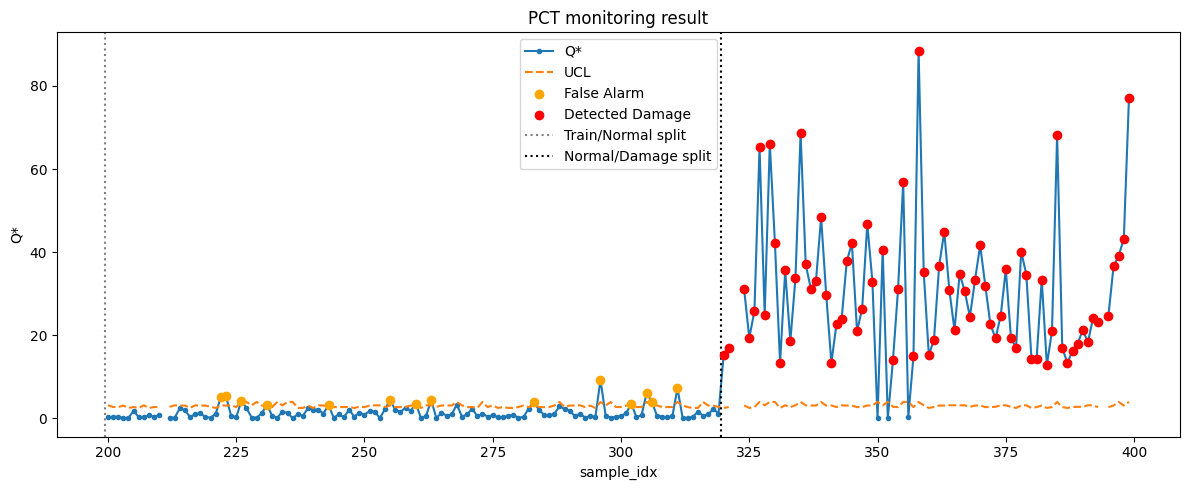

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(result_all["sample_idx"], result_all["Q_star"], label="Q*", marker="o", ms=3)
plt.plot(result_all["sample_idx"], result_all["UCL"], label="UCL", linestyle="--")

false_alarm_pts = result_all[(result_all["status"] == "Normal") & (result_all["alarm"] == True)]
detected_damage_pts = result_all[(result_all["status"] == "Damaged") & (result_all["alarm"] == True)]

plt.scatter(false_alarm_pts["sample_idx"], false_alarm_pts["Q_star"],
            color="orange", label="False Alarm", zorder=3)

plt.scatter(detected_damage_pts["sample_idx"], detected_damage_pts["Q_star"],
            color="red", label="Detected Damage", zorder=3)

plt.axvline(199.5, color="gray", linestyle=":", label="Train/Normal split")
plt.axvline(319.5, color="black", linestyle=":", label="Normal/Damage split")

plt.xlabel("sample_idx")
plt.ylabel("Q*")
plt.title("PCT monitoring result")
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
from pct import PCTChart

# --------------------------------------------------
# 1) Use preloaded dataframe: residual5
# --------------------------------------------------
df = residual5.copy()

# feature columns: exclude index/status columns
feature_cols = ['0', '2', '3', '4']

X = df[feature_cols].copy()
y = df["status"].copy()

# numeric conversion
X = X.apply(pd.to_numeric, errors="coerce")

# --------------------------------------------------
# 2) Split
# --------------------------------------------------
train_mask = df["sample_idx"].between(0, 199)
normal_mask = df["sample_idx"].between(200, 319)
damaged_mask = df["sample_idx"].between(320, 399)

X_train = X.loc[train_mask].to_numpy(dtype=float)
X_normal = X.loc[normal_mask].to_numpy(dtype=float)
X_damaged = X.loc[damaged_mask].to_numpy(dtype=float)

y_normal = y.loc[normal_mask].to_numpy()
y_damaged = y.loc[damaged_mask].to_numpy()

# --------------------------------------------------
# 3) Fit PCT
# --------------------------------------------------
pct = PCTChart(alpha=0.05)
pct.fit(X_train)

# --------------------------------------------------
# 4) Score
# --------------------------------------------------
res_normal = pct.score_samples(X_normal)
res_damaged = pct.score_samples(X_damaged)

normal_alarm = res_normal.alarms
damaged_alarm = res_damaged.alarms

far = normal_alarm.mean()
detection_rate = damaged_alarm.mean()

# --------------------------------------------------
# 5) Summary
# --------------------------------------------------
print("=" * 70)
print("PCT Evaluation Summary")
print("=" * 70)
print(f"# train samples         : {len(X_train)}")
print(f"# unseen normal samples : {len(X_normal)}")
print(f"# damaged samples       : {len(X_damaged)}")
print("-" * 70)
print(f"False Alarm Rate (200~319) : {far:.4f} ({normal_alarm.sum()}/{len(normal_alarm)})")
print(f"Detection Rate  (320~399) : {detection_rate:.4f} ({damaged_alarm.sum()}/{len(damaged_alarm)})")
print("=" * 70)

# --------------------------------------------------
# 6) Detailed result table
# --------------------------------------------------
result_normal = pd.DataFrame({
    "sample_idx": df.loc[normal_mask, "sample_idx"].values,
    "status": y_normal,
    "Q_star": res_normal.q_values,
    "UCL": res_normal.ucls,
    "alarm": res_normal.alarms,
    "n_obs_vars": res_normal.n_obs_vars,
    "df": res_normal.dfs,
    "scale": res_normal.scales,
})

result_damaged = pd.DataFrame({
    "sample_idx": df.loc[damaged_mask, "sample_idx"].values,
    "status": y_damaged,
    "Q_star": res_damaged.q_values,
    "UCL": res_damaged.ucls,
    "alarm": res_damaged.alarms,
    "n_obs_vars": res_damaged.n_obs_vars,
    "df": res_damaged.dfs,
    "scale": res_damaged.scales,
})

result_all = pd.concat([result_normal, result_damaged], axis=0, ignore_index=True)

# --------------------------------------------------
# 7) Confusion summary
# --------------------------------------------------
tp = int(damaged_alarm.sum())
fn = int((~damaged_alarm).sum())
fp = int(normal_alarm.sum())
tn = int((~normal_alarm).sum())

print("\nConfusion-like summary")
print("-" * 70)
print(f"TN (normal -> normal) : {tn}")
print(f"FP (normal -> alarm)  : {fp}")
print(f"FN (damage -> normal) : {fn}")
print(f"TP (damage -> alarm)  : {tp}")

# 필요하면 저장
# result_all.to_csv("pct_results_frac_0.1.csv", index=False)


PCT Evaluation Summary
# train samples         : 200
# unseen normal samples : 120
# damaged samples       : 80
----------------------------------------------------------------------
False Alarm Rate (200~319) : 0.1083 (13/120)
Detection Rate  (320~399) : 0.9125 (73/80)

Confusion-like summary
----------------------------------------------------------------------
TN (normal -> normal) : 107
FP (normal -> alarm)  : 13
FN (damage -> normal) : 7
TP (damage -> alarm)  : 73


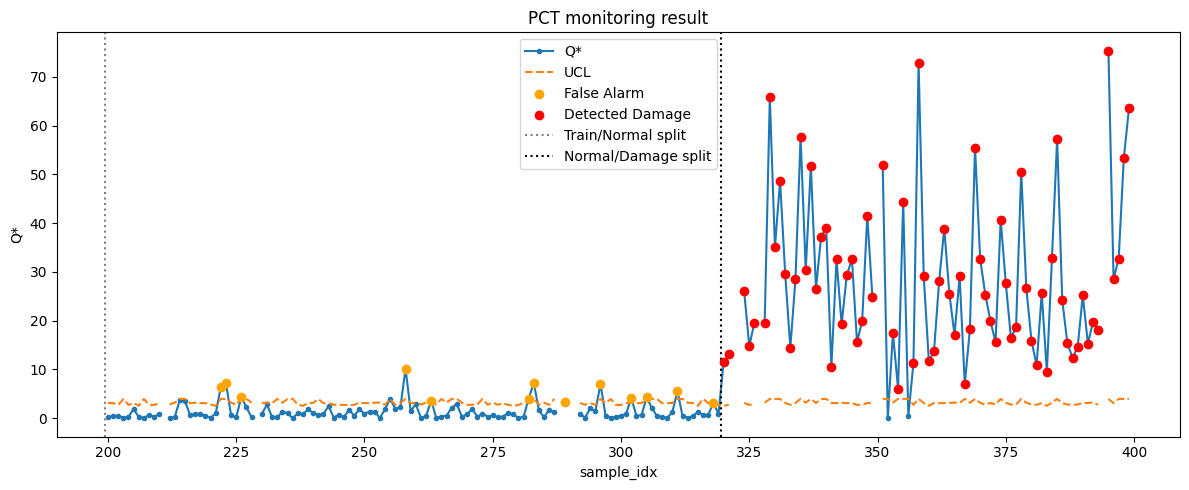

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(result_all["sample_idx"], result_all["Q_star"], label="Q*", marker="o", ms=3)
plt.plot(result_all["sample_idx"], result_all["UCL"], label="UCL", linestyle="--")

false_alarm_pts = result_all[(result_all["status"] == "Normal") & (result_all["alarm"] == True)]
detected_damage_pts = result_all[(result_all["status"] == "Damaged") & (result_all["alarm"] == True)]

plt.scatter(false_alarm_pts["sample_idx"], false_alarm_pts["Q_star"],
            color="orange", label="False Alarm", zorder=3)

plt.scatter(detected_damage_pts["sample_idx"], detected_damage_pts["Q_star"],
            color="red", label="Detected Damage", zorder=3)

plt.axvline(199.5, color="gray", linestyle=":", label="Train/Normal split")
plt.axvline(319.5, color="black", linestyle=":", label="Normal/Damage split")

plt.xlabel("sample_idx")
plt.ylabel("Q*")
plt.title("PCT monitoring result")
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
from pct import PCTChart

# --------------------------------------------------
# 1) Use preloaded dataframe: residual6
# --------------------------------------------------
df = residual6.copy()

# feature columns: exclude index/status columns
feature_cols = ['0', '2', '3', '4']

X = df[feature_cols].copy()
y = df["status"].copy()

# numeric conversion
X = X.apply(pd.to_numeric, errors="coerce")

# --------------------------------------------------
# 2) Split
# --------------------------------------------------
train_mask = df["sample_idx"].between(0, 199)
normal_mask = df["sample_idx"].between(200, 319)
damaged_mask = df["sample_idx"].between(320, 399)

X_train = X.loc[train_mask].to_numpy(dtype=float)
X_normal = X.loc[normal_mask].to_numpy(dtype=float)
X_damaged = X.loc[damaged_mask].to_numpy(dtype=float)

y_normal = y.loc[normal_mask].to_numpy()
y_damaged = y.loc[damaged_mask].to_numpy()

# --------------------------------------------------
# 3) Fit PCT
# --------------------------------------------------
pct = PCTChart(alpha=0.05)
pct.fit(X_train)

# --------------------------------------------------
# 4) Score
# --------------------------------------------------
res_normal = pct.score_samples(X_normal)
res_damaged = pct.score_samples(X_damaged)

normal_alarm = res_normal.alarms
damaged_alarm = res_damaged.alarms

far = normal_alarm.mean()
detection_rate = damaged_alarm.mean()

# --------------------------------------------------
# 5) Summary
# --------------------------------------------------
print("=" * 70)
print("PCT Evaluation Summary")
print("=" * 70)
print(f"# train samples         : {len(X_train)}")
print(f"# unseen normal samples : {len(X_normal)}")
print(f"# damaged samples       : {len(X_damaged)}")
print("-" * 70)
print(f"False Alarm Rate (200~319) : {far:.4f} ({normal_alarm.sum()}/{len(normal_alarm)})")
print(f"Detection Rate  (320~399) : {detection_rate:.4f} ({damaged_alarm.sum()}/{len(damaged_alarm)})")
print("=" * 70)

# --------------------------------------------------
# 6) Detailed result table
# --------------------------------------------------
result_normal = pd.DataFrame({
    "sample_idx": df.loc[normal_mask, "sample_idx"].values,
    "status": y_normal,
    "Q_star": res_normal.q_values,
    "UCL": res_normal.ucls,
    "alarm": res_normal.alarms,
    "n_obs_vars": res_normal.n_obs_vars,
    "df": res_normal.dfs,
    "scale": res_normal.scales,
})

result_damaged = pd.DataFrame({
    "sample_idx": df.loc[damaged_mask, "sample_idx"].values,
    "status": y_damaged,
    "Q_star": res_damaged.q_values,
    "UCL": res_damaged.ucls,
    "alarm": res_damaged.alarms,
    "n_obs_vars": res_damaged.n_obs_vars,
    "df": res_damaged.dfs,
    "scale": res_damaged.scales,
})

result_all = pd.concat([result_normal, result_damaged], axis=0, ignore_index=True)

# --------------------------------------------------
# 7) Confusion summary
# --------------------------------------------------
tp = int(damaged_alarm.sum())
fn = int((~damaged_alarm).sum())
fp = int(normal_alarm.sum())
tn = int((~normal_alarm).sum())

print("\nConfusion-like summary")
print("-" * 70)
print(f"TN (normal -> normal) : {tn}")
print(f"FP (normal -> alarm)  : {fp}")
print(f"FN (damage -> normal) : {fn}")
print(f"TP (damage -> alarm)  : {tp}")

# 필요하면 저장
# result_all.to_csv("pct_results_frac_0.1.csv", index=False)


PCT Evaluation Summary
# train samples         : 200
# unseen normal samples : 120
# damaged samples       : 80
----------------------------------------------------------------------
False Alarm Rate (200~319) : 0.0833 (10/120)
Detection Rate  (320~399) : 0.8500 (68/80)

Confusion-like summary
----------------------------------------------------------------------
TN (normal -> normal) : 110
FP (normal -> alarm)  : 10
FN (damage -> normal) : 12
TP (damage -> alarm)  : 68


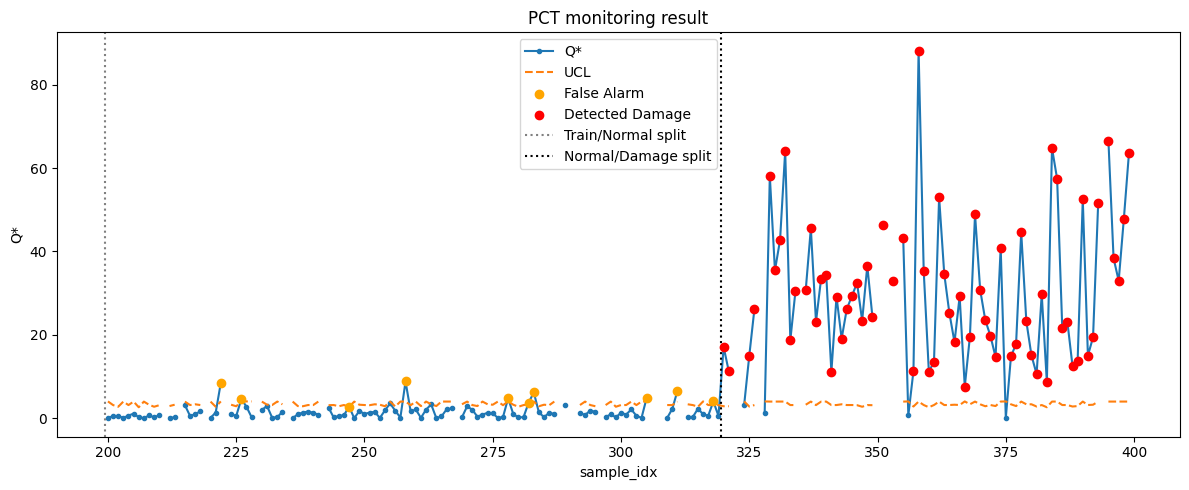

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(result_all["sample_idx"], result_all["Q_star"], label="Q*", marker="o", ms=3)
plt.plot(result_all["sample_idx"], result_all["UCL"], label="UCL", linestyle="--")

false_alarm_pts = result_all[(result_all["status"] == "Normal") & (result_all["alarm"] == True)]
detected_damage_pts = result_all[(result_all["status"] == "Damaged") & (result_all["alarm"] == True)]

plt.scatter(false_alarm_pts["sample_idx"], false_alarm_pts["Q_star"],
            color="orange", label="False Alarm", zorder=3)

plt.scatter(detected_damage_pts["sample_idx"], detected_damage_pts["Q_star"],
            color="red", label="Detected Damage", zorder=3)

plt.axvline(199.5, color="gray", linestyle=":", label="Train/Normal split")
plt.axvline(319.5, color="black", linestyle=":", label="Normal/Damage split")

plt.xlabel("sample_idx")
plt.ylabel("Q*")
plt.title("PCT monitoring result")
plt.legend()
plt.tight_layout()
plt.show()

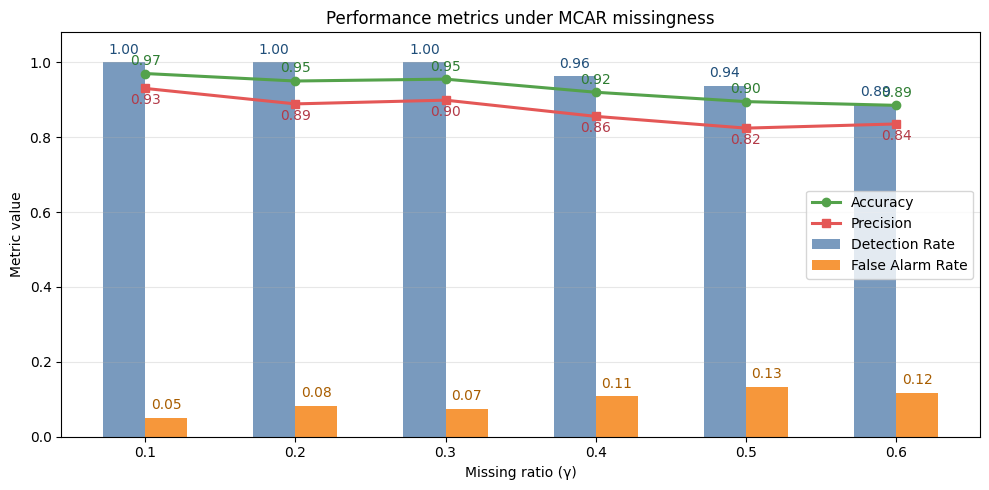

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.DataFrame({
    "gamma": [0.1, 0.2, 0.3, 0.4, 0.5, 0.6],
    "TN": [114, 110, 111, 107, 104, 106],
    "FP": [6, 10, 9, 13, 16, 14],
    "FN": [0, 0, 0, 3, 5, 9],
    "TP": [80, 80, 80, 77, 75, 71],
})

df["FPR"] = df["FP"] / (df["FP"] + df["TN"])
df["TPR"] = df["TP"] / (df["TP"] + df["FN"])
df["Accuracy"] = (df["TP"] + df["TN"]) / (df["TP"] + df["TN"] + df["FP"] + df["FN"])
df["Precision"] = df["TP"] / (df["TP"] + df["FP"])

x = np.arange(len(df))
w = 0.28

fig, ax = plt.subplots(figsize=(10, 5))

# Bar plots
bars1 = ax.bar(x - w/2, df["TPR"], width=w, color="#4C78A8", alpha=0.75, label="Detection Rate")
bars2 = ax.bar(x + w/2, df["FPR"], width=w, color="#F58518", alpha=0.85, label="False Alarm Rate")

# Line plots
ax.plot(x, df["Accuracy"], color="#54A24B", marker="o", linewidth=2.2, label="Accuracy")
ax.plot(x, df["Precision"], color="#E45756", marker="s", linewidth=2.2, label="Precision")

# Line value labels
for i, v in enumerate(df["Accuracy"]):
    ax.text(i, v + 0.015, f"{v:.2f}", ha="center", va="bottom", fontsize=10, color="#2E7D32")

for i, v in enumerate(df["Precision"]):
    ax.text(i, v - 0.05, f"{v:.2f}", ha="center", va="bottom", fontsize=10, color="#B23A48")

# Bar value labels
for bar in bars1:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.015,
        f"{h:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#1F4E79"
    )

for bar in bars2:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.015,
        f"{h:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#A85D00"
    )

ax.set_xticks(x)
ax.set_xticklabels(df["gamma"])
ax.set_xlabel("Missing ratio (γ)")
ax.set_ylabel("Metric value")
ax.set_title("Performance metrics under MCAR missingness")
ax.set_ylim(0, 1.08)
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="center right", frameon=True)

plt.tight_layout()
plt.show()


현재, 모델 자체는 손상 구간과 정상 구간을 구분하는 신호를 가지고 있다. 하지만 threshold/UCL calibration은 기대한 수준으로 맞지 않고 있다.

유의수준($\alpha$)보다 높게 나오는 이유: 훈련 데이터에서 결측 패턴과 개수를 학습하였으나, 새로 들어오는 샘플의 결측 패턴과 개수가 새로운 형태여서 그런 것, 이에 대한 논리를 뒷받침하는 근거로 같은 열에 대해서 결측이 일어나는 상황에서의 유의수준은 $\gamma=0.1$일 때, 0.025이고, $\gamma=0.6$일때, 0.075로 나오는 결과를 제시한다

idea) 오경보율이 떴을 때, 이 오경보율이 그냥 오경보율이다!가 아니라 오경보율 확률 80%, 20% 이렇게 추가적인 지표가 추가되면 좋을 것 같다. -> threshold calibration 개선 -> 여기에 cp를 사용할 수 있지 않을까?

In [29]:
from pct import PCTChart

# --------------------------------------------------
# 1) Use preloaded dataframe: mode_residual1
# --------------------------------------------------
df = mode_residual1.copy()

# feature columns: exclude index/status columns
feature_cols = [c for c in df.columns if c not in ["sample_idx", "status"]]

X = df[feature_cols].copy()
y = df["status"].copy()

# numeric conversion
X = X.apply(pd.to_numeric, errors="coerce")

# --------------------------------------------------
# 2) Split
# --------------------------------------------------
train_mask = df["sample_idx"].between(0, 199)
normal_mask = df["sample_idx"].between(200, 319)
damaged_mask = df["sample_idx"].between(320, 399)

X_train = X.loc[train_mask].to_numpy(dtype=float)
X_normal = X.loc[normal_mask].to_numpy(dtype=float)
X_damaged = X.loc[damaged_mask].to_numpy(dtype=float)

y_normal = y.loc[normal_mask].to_numpy()
y_damaged = y.loc[damaged_mask].to_numpy()

# --------------------------------------------------
# 3) Fit PCT
# --------------------------------------------------
pct = PCTChart(alpha=0.05)
pct.fit(X_train)

# --------------------------------------------------
# 4) Score
# --------------------------------------------------
res_normal = pct.score_samples(X_normal)
res_damaged = pct.score_samples(X_damaged)

normal_alarm = res_normal.alarms
damaged_alarm = res_damaged.alarms

far = normal_alarm.mean()
detection_rate = damaged_alarm.mean()

# --------------------------------------------------
# 5) Summary
# --------------------------------------------------
print("=" * 70)
print("PCT Evaluation Summary")
print("=" * 70)
print(f"# train samples         : {len(X_train)}")
print(f"# unseen normal samples : {len(X_normal)}")
print(f"# damaged samples       : {len(X_damaged)}")
print("-" * 70)
print(f"False Alarm Rate (200~319) : {far:.4f} ({normal_alarm.sum()}/{len(normal_alarm)})")
print(f"Detection Rate  (320~399) : {detection_rate:.4f} ({damaged_alarm.sum()}/{len(damaged_alarm)})")
print("=" * 70)

# --------------------------------------------------
# 6) Detailed result table
# --------------------------------------------------
result_normal = pd.DataFrame({
    "sample_idx": df.loc[normal_mask, "sample_idx"].values,
    "status": y_normal,
    "Q_star": res_normal.q_values,
    "UCL": res_normal.ucls,
    "alarm": res_normal.alarms,
    "n_obs_vars": res_normal.n_obs_vars,
    "df": res_normal.dfs,
    "scale": res_normal.scales,
})

result_damaged = pd.DataFrame({
    "sample_idx": df.loc[damaged_mask, "sample_idx"].values,
    "status": y_damaged,
    "Q_star": res_damaged.q_values,
    "UCL": res_damaged.ucls,
    "alarm": res_damaged.alarms,
    "n_obs_vars": res_damaged.n_obs_vars,
    "df": res_damaged.dfs,
    "scale": res_damaged.scales,
})

result_all = pd.concat([result_normal, result_damaged], axis=0, ignore_index=True)

# --------------------------------------------------
# 7) Confusion summary
# --------------------------------------------------
tp = int(damaged_alarm.sum())
fn = int((~damaged_alarm).sum())
fp = int(normal_alarm.sum())
tn = int((~normal_alarm).sum())

print("\nConfusion-like summary")
print("-" * 70)
print(f"TN (normal -> normal) : {tn}")
print(f"FP (normal -> alarm)  : {fp}")
print(f"FN (damage -> normal) : {fn}")
print(f"TP (damage -> alarm)  : {tp}")

# 필요하면 저장
# result_all.to_csv("pct_results_frac_0.1.csv", index=False)


PCT Evaluation Summary
# train samples         : 200
# unseen normal samples : 120
# damaged samples       : 80
----------------------------------------------------------------------
False Alarm Rate (200~319) : 0.0250 (3/120)
Detection Rate  (320~399) : 1.0000 (80/80)

Confusion-like summary
----------------------------------------------------------------------
TN (normal -> normal) : 117
FP (normal -> alarm)  : 3
FN (damage -> normal) : 0
TP (damage -> alarm)  : 80


In [30]:
from pct import PCTChart

# --------------------------------------------------
# 1) Use preloaded dataframe: mode_residual3
# --------------------------------------------------
df = mode_residual3.copy()

# feature columns: exclude index/status columns
feature_cols = [c for c in df.columns if c not in ["sample_idx", "status"]]

X = df[feature_cols].copy()
y = df["status"].copy()

# numeric conversion
X = X.apply(pd.to_numeric, errors="coerce")

# --------------------------------------------------
# 2) Split
# --------------------------------------------------
train_mask = df["sample_idx"].between(0, 199)
normal_mask = df["sample_idx"].between(200, 319)
damaged_mask = df["sample_idx"].between(320, 399)

X_train = X.loc[train_mask].to_numpy(dtype=float)
X_normal = X.loc[normal_mask].to_numpy(dtype=float)
X_damaged = X.loc[damaged_mask].to_numpy(dtype=float)

y_normal = y.loc[normal_mask].to_numpy()
y_damaged = y.loc[damaged_mask].to_numpy()

# --------------------------------------------------
# 3) Fit PCT
# --------------------------------------------------
pct = PCTChart(alpha=0.05)
pct.fit(X_train)

# --------------------------------------------------
# 4) Score
# --------------------------------------------------
res_normal = pct.score_samples(X_normal)
res_damaged = pct.score_samples(X_damaged)

normal_alarm = res_normal.alarms
damaged_alarm = res_damaged.alarms

far = normal_alarm.mean()
detection_rate = damaged_alarm.mean()

# --------------------------------------------------
# 5) Summary
# --------------------------------------------------
print("=" * 70)
print("PCT Evaluation Summary")
print("=" * 70)
print(f"# train samples         : {len(X_train)}")
print(f"# unseen normal samples : {len(X_normal)}")
print(f"# damaged samples       : {len(X_damaged)}")
print("-" * 70)
print(f"False Alarm Rate (200~319) : {far:.4f} ({normal_alarm.sum()}/{len(normal_alarm)})")
print(f"Detection Rate  (320~399) : {detection_rate:.4f} ({damaged_alarm.sum()}/{len(damaged_alarm)})")
print("=" * 70)

# --------------------------------------------------
# 6) Detailed result table
# --------------------------------------------------
result_normal = pd.DataFrame({
    "sample_idx": df.loc[normal_mask, "sample_idx"].values,
    "status": y_normal,
    "Q_star": res_normal.q_values,
    "UCL": res_normal.ucls,
    "alarm": res_normal.alarms,
    "n_obs_vars": res_normal.n_obs_vars,
    "df": res_normal.dfs,
    "scale": res_normal.scales,
})

result_damaged = pd.DataFrame({
    "sample_idx": df.loc[damaged_mask, "sample_idx"].values,
    "status": y_damaged,
    "Q_star": res_damaged.q_values,
    "UCL": res_damaged.ucls,
    "alarm": res_damaged.alarms,
    "n_obs_vars": res_damaged.n_obs_vars,
    "df": res_damaged.dfs,
    "scale": res_damaged.scales,
})

result_all = pd.concat([result_normal, result_damaged], axis=0, ignore_index=True)

# --------------------------------------------------
# 7) Confusion summary
# --------------------------------------------------
tp = int(damaged_alarm.sum())
fn = int((~damaged_alarm).sum())
fp = int(normal_alarm.sum())
tn = int((~normal_alarm).sum())

print("\nConfusion-like summary")
print("-" * 70)
print(f"TN (normal -> normal) : {tn}")
print(f"FP (normal -> alarm)  : {fp}")
print(f"FN (damage -> normal) : {fn}")
print(f"TP (damage -> alarm)  : {tp}")

# 필요하면 저장
# result_all.to_csv("pct_results_frac_0.1.csv", index=False)


PCT Evaluation Summary
# train samples         : 200
# unseen normal samples : 120
# damaged samples       : 80
----------------------------------------------------------------------
False Alarm Rate (200~319) : 0.0500 (6/120)
Detection Rate  (320~399) : 1.0000 (80/80)

Confusion-like summary
----------------------------------------------------------------------
TN (normal -> normal) : 114
FP (normal -> alarm)  : 6
FN (damage -> normal) : 0
TP (damage -> alarm)  : 80


In [31]:
from pct import PCTChart

# --------------------------------------------------
# 1) Use preloaded dataframe: mode_residual6
# --------------------------------------------------
df = mode_residual6.copy()

# feature columns: exclude index/status columns
feature_cols = [c for c in df.columns if c not in ["sample_idx", "status"]]

X = df[feature_cols].copy()
y = df["status"].copy()

# numeric conversion
X = X.apply(pd.to_numeric, errors="coerce")

# --------------------------------------------------
# 2) Split
# --------------------------------------------------
train_mask = df["sample_idx"].between(0, 199)
normal_mask = df["sample_idx"].between(200, 319)
damaged_mask = df["sample_idx"].between(320, 399)

X_train = X.loc[train_mask].to_numpy(dtype=float)
X_normal = X.loc[normal_mask].to_numpy(dtype=float)
X_damaged = X.loc[damaged_mask].to_numpy(dtype=float)

y_normal = y.loc[normal_mask].to_numpy()
y_damaged = y.loc[damaged_mask].to_numpy()

# --------------------------------------------------
# 3) Fit PCT
# --------------------------------------------------
pct = PCTChart(alpha=0.05)
pct.fit(X_train)

# --------------------------------------------------
# 4) Score
# --------------------------------------------------
res_normal = pct.score_samples(X_normal)
res_damaged = pct.score_samples(X_damaged)

normal_alarm = res_normal.alarms
damaged_alarm = res_damaged.alarms

far = normal_alarm.mean()
detection_rate = damaged_alarm.mean()

# --------------------------------------------------
# 5) Summary
# --------------------------------------------------
print("=" * 70)
print("PCT Evaluation Summary")
print("=" * 70)
print(f"# train samples         : {len(X_train)}")
print(f"# unseen normal samples : {len(X_normal)}")
print(f"# damaged samples       : {len(X_damaged)}")
print("-" * 70)
print(f"False Alarm Rate (200~319) : {far:.4f} ({normal_alarm.sum()}/{len(normal_alarm)})")
print(f"Detection Rate  (320~399) : {detection_rate:.4f} ({damaged_alarm.sum()}/{len(damaged_alarm)})")
print("=" * 70)

# --------------------------------------------------
# 6) Detailed result table
# --------------------------------------------------
result_normal = pd.DataFrame({
    "sample_idx": df.loc[normal_mask, "sample_idx"].values,
    "status": y_normal,
    "Q_star": res_normal.q_values,
    "UCL": res_normal.ucls,
    "alarm": res_normal.alarms,
    "n_obs_vars": res_normal.n_obs_vars,
    "df": res_normal.dfs,
    "scale": res_normal.scales,
})

result_damaged = pd.DataFrame({
    "sample_idx": df.loc[damaged_mask, "sample_idx"].values,
    "status": y_damaged,
    "Q_star": res_damaged.q_values,
    "UCL": res_damaged.ucls,
    "alarm": res_damaged.alarms,
    "n_obs_vars": res_damaged.n_obs_vars,
    "df": res_damaged.dfs,
    "scale": res_damaged.scales,
})

result_all = pd.concat([result_normal, result_damaged], axis=0, ignore_index=True)

# --------------------------------------------------
# 7) Confusion summary
# --------------------------------------------------
tp = int(damaged_alarm.sum())
fn = int((~damaged_alarm).sum())
fp = int(normal_alarm.sum())
tn = int((~normal_alarm).sum())

print("\nConfusion-like summary")
print("-" * 70)
print(f"TN (normal -> normal) : {tn}")
print(f"FP (normal -> alarm)  : {fp}")
print(f"FN (damage -> normal) : {fn}")
print(f"TP (damage -> alarm)  : {tp}")

# 필요하면 저장
# result_all.to_csv("pct_results_frac_0.1.csv", index=False)


PCT Evaluation Summary
# train samples         : 200
# unseen normal samples : 120
# damaged samples       : 80
----------------------------------------------------------------------
False Alarm Rate (200~319) : 0.0750 (9/120)
Detection Rate  (320~399) : 1.0000 (80/80)

Confusion-like summary
----------------------------------------------------------------------
TN (normal -> normal) : 111
FP (normal -> alarm)  : 9
FN (damage -> normal) : 0
TP (damage -> alarm)  : 80


1. 가장 추천하는 핵심 키워드 조합
당신 상황에 가장 잘 맞는 축은 4개입니다.

conformal prediction<br>
anomaly detection / novelty detection<br>
monitoring / process monitoring / online monitoring<br>
calibration / threshold / p-value / false alarm control<br>
<br>
추천 검색식 1<br>
가장 기본<br>
"conformal prediction" anomaly detection threshold calibration<br>
이건 가장 먼저 해볼 만합니다.<br>
<br>
추천 검색식 2<br>
당신 목적에 더 가까움<br>
"conformal prediction" "false alarm rate" anomaly detection<br>
"conformal prediction" alarm calibration monitoring<br>
"conformal prediction" threshold control anomaly detection<br>
이건 오경보율 제어 관점의 논문을 잡는 데 좋습니다.<br>
<br>
추천 검색식 3<br>
모니터링/관리도 느낌<br>
"conformal prediction" process monitoring<br>
"conformal prediction" statistical process monitoring<br>
"conformal p-value" control chart<br>
"conformal prediction" control chart anomaly detection<br>
이건 당신이 지금 사실상 control chart / monitoring statistic / UCL 구조를 보고 있기 때문에 중요합니다.<br>
<br>
추천 검색식 4<br>
온라인 탐지/변화탐지 쪽<br>
"conformal anomaly detection" online<br>
"conformal prediction" change detection<br>
"conformal p-values" sequential monitoring<br>
"conformal martingales" change detection<br>

In [32]:
from pct import PCTChart

# --------------------------------------------------
# 1) Use preloaded dataframe: residual3
# --------------------------------------------------
df = residual4.copy()

feature_cols = [c for c in df.columns if c not in ["sample_idx", "status"]]

X = df[feature_cols].copy()
y = df["status"].copy()

X = X.apply(pd.to_numeric, errors="coerce")

# --------------------------------------------------
# 2) Split
# --------------------------------------------------
train_mask = df["sample_idx"].between(0, 199)

# recommended split for conformal
cal_mask = df["sample_idx"].between(200, 259)      # normal calibration
normal_test_mask = df["sample_idx"].between(260, 319)  # unseen normal test
damaged_mask = df["sample_idx"].between(320, 399)  # damaged test

X_train = X.loc[train_mask].to_numpy(dtype=float)
X_cal = X.loc[cal_mask].to_numpy(dtype=float)
X_normal_test = X.loc[normal_test_mask].to_numpy(dtype=float)
X_damaged = X.loc[damaged_mask].to_numpy(dtype=float)

y_cal = y.loc[cal_mask].to_numpy()
y_normal_test = y.loc[normal_test_mask].to_numpy()
y_damaged = y.loc[damaged_mask].to_numpy()

sample_idx_cal = df.loc[cal_mask, "sample_idx"].to_numpy()
sample_idx_normal_test = df.loc[normal_test_mask, "sample_idx"].to_numpy()
sample_idx_damaged = df.loc[damaged_mask, "sample_idx"].to_numpy()

# --------------------------------------------------
# 3) Fit PCT on Phase I normal data
# --------------------------------------------------
pct = PCTChart(alpha=0.05)
pct.fit(X_train)

# --------------------------------------------------
# 4) Get PCT scores
# --------------------------------------------------
res_cal = pct.score_samples(X_cal)
res_normal_test = pct.score_samples(X_normal_test)
res_damaged = pct.score_samples(X_damaged)

cal_scores = res_cal.q_values.copy()

# remove invalid calibration scores if any
cal_scores = cal_scores[np.isfinite(cal_scores)]

if len(cal_scores) == 0:
    raise ValueError("No valid calibration scores were obtained.")

# --------------------------------------------------
# 5) Conformal p-value function
# --------------------------------------------------
def conformal_pvalues(cal_scores, test_scores):
    cal_scores = np.asarray(cal_scores, dtype=float)
    test_scores = np.asarray(test_scores, dtype=float)

    pvals = np.full(len(test_scores), np.nan, dtype=float)

    for i, s in enumerate(test_scores):
        if np.isfinite(s):
            pvals[i] = (1.0 + np.sum(cal_scores >= s)) / (len(cal_scores) + 1.0)

    return pvals

p_normal = conformal_pvalues(cal_scores, res_normal_test.q_values)
p_damaged = conformal_pvalues(cal_scores, res_damaged.q_values)

normal_alarm_cp = p_normal <= 0.05
damaged_alarm_cp = p_damaged <= 0.05

far_cp = np.nanmean(normal_alarm_cp)
dr_cp = np.nanmean(damaged_alarm_cp)

# --------------------------------------------------
# 6) Compare with original PCT alarm
# --------------------------------------------------
far_pct = np.mean(res_normal_test.alarms)
dr_pct = np.mean(res_damaged.alarms)

print("=" * 80)
print("Comparison: Original PCT vs Global Conformal Calibration on PCT Score")
print("=" * 80)
print(f"# train samples            : {len(X_train)}")
print(f"# calibration normal       : {len(X_cal)}")
print(f"# unseen normal test       : {len(X_normal_test)}")
print(f"# damaged test             : {len(X_damaged)}")
print("-" * 80)
print(f"[Original PCT] FAR        : {far_pct:.4f} ({res_normal_test.alarms.sum()}/{len(res_normal_test.alarms)})")
print(f"[Original PCT] DR         : {dr_pct:.4f} ({res_damaged.alarms.sum()}/{len(res_damaged.alarms)})")
print("-" * 80)
print(f"[Global CP]    FAR        : {far_cp:.4f} ({normal_alarm_cp.sum()}/{len(normal_alarm_cp)})")
print(f"[Global CP]    DR         : {dr_cp:.4f} ({damaged_alarm_cp.sum()}/{len(damaged_alarm_cp)})")
print("=" * 80)

# --------------------------------------------------
# 7) Detailed result tables
# --------------------------------------------------
result_normal_cp = pd.DataFrame({
    "sample_idx": sample_idx_normal_test,
    "status": y_normal_test,
    "Q_star": res_normal_test.q_values,
    "PCT_UCL": res_normal_test.ucls,
    "PCT_alarm": res_normal_test.alarms,
    "cp_pvalue": p_normal,
    "CP_alarm": normal_alarm_cp,
    "n_obs_vars": res_normal_test.n_obs_vars,
    "df": res_normal_test.dfs,
    "scale": res_normal_test.scales,
})

result_damaged_cp = pd.DataFrame({
    "sample_idx": sample_idx_damaged,
    "status": y_damaged,
    "Q_star": res_damaged.q_values,
    "PCT_UCL": res_damaged.ucls,
    "PCT_alarm": res_damaged.alarms,
    "cp_pvalue": p_damaged,
    "CP_alarm": damaged_alarm_cp,
    "n_obs_vars": res_damaged.n_obs_vars,
    "df": res_damaged.dfs,
    "scale": res_damaged.scales,
})

result_all_cp = pd.concat([result_normal_cp, result_damaged_cp], axis=0, ignore_index=True)

print("\n[Global CP] Confusion-like summary")
print("-" * 80)
tp = int(np.nansum(damaged_alarm_cp))
fn = int(np.sum(~damaged_alarm_cp))
fp = int(np.nansum(normal_alarm_cp))
tn = int(np.sum(~normal_alarm_cp))

print(f"TN (normal -> normal) : {tn}")
print(f"FP (normal -> alarm)  : {fp}")
print(f"FN (damage -> normal) : {fn}")
print(f"TP (damage -> alarm)  : {tp}")

# optional save
# result_all_cp.to_csv("pct_global_cp_results.csv", index=False)


Comparison: Original PCT vs Global Conformal Calibration on PCT Score
# train samples            : 200
# calibration normal       : 60
# unseen normal test       : 60
# damaged test             : 80
--------------------------------------------------------------------------------
[Original PCT] FAR        : 0.1333 (8/60)
[Original PCT] DR         : 0.9625 (77/80)
--------------------------------------------------------------------------------
[Global CP]    FAR        : 0.1167 (7/60)
[Global CP]    DR         : 0.9625 (77/80)

[Global CP] Confusion-like summary
--------------------------------------------------------------------------------
TN (normal -> normal) : 53
FP (normal -> alarm)  : 7
FN (damage -> normal) : 3
TP (damage -> alarm)  : 77


In [33]:
from pct import PCTChart

# --------------------------------------------------
# 1) Use preloaded dataframe: residual5
# --------------------------------------------------
df = residual6.copy()

feature_cols = [c for c in df.columns if c not in ["sample_idx", "status"]]

X = df[feature_cols].copy()
y = df["status"].copy()

X = X.apply(pd.to_numeric, errors="coerce")

# --------------------------------------------------
# 2) Split
# --------------------------------------------------
train_mask = df["sample_idx"].between(0, 199)

# recommended split for conformal
cal_mask = df["sample_idx"].between(200, 259)      # normal calibration
normal_test_mask = df["sample_idx"].between(260, 319)  # unseen normal test
damaged_mask = df["sample_idx"].between(320, 399)  # damaged test

X_train = X.loc[train_mask].to_numpy(dtype=float)
X_cal = X.loc[cal_mask].to_numpy(dtype=float)
X_normal_test = X.loc[normal_test_mask].to_numpy(dtype=float)
X_damaged = X.loc[damaged_mask].to_numpy(dtype=float)

y_cal = y.loc[cal_mask].to_numpy()
y_normal_test = y.loc[normal_test_mask].to_numpy()
y_damaged = y.loc[damaged_mask].to_numpy()

sample_idx_cal = df.loc[cal_mask, "sample_idx"].to_numpy()
sample_idx_normal_test = df.loc[normal_test_mask, "sample_idx"].to_numpy()
sample_idx_damaged = df.loc[damaged_mask, "sample_idx"].to_numpy()

# --------------------------------------------------
# 3) Fit PCT on Phase I normal data
# --------------------------------------------------
pct = PCTChart(alpha=0.05)
pct.fit(X_train)

# --------------------------------------------------
# 4) Get PCT scores
# --------------------------------------------------
res_cal = pct.score_samples(X_cal)
res_normal_test = pct.score_samples(X_normal_test)
res_damaged = pct.score_samples(X_damaged)

cal_scores = res_cal.q_values.copy()

# remove invalid calibration scores if any
cal_scores = cal_scores[np.isfinite(cal_scores)]

if len(cal_scores) == 0:
    raise ValueError("No valid calibration scores were obtained.")

# --------------------------------------------------
# 5) Conformal p-value function
# --------------------------------------------------
def conformal_pvalues(cal_scores, test_scores):
    cal_scores = np.asarray(cal_scores, dtype=float)
    test_scores = np.asarray(test_scores, dtype=float)

    pvals = np.full(len(test_scores), np.nan, dtype=float)

    for i, s in enumerate(test_scores):
        if np.isfinite(s):
            pvals[i] = (1.0 + np.sum(cal_scores >= s)) / (len(cal_scores) + 1.0)

    return pvals

p_normal = conformal_pvalues(cal_scores, res_normal_test.q_values)
p_damaged = conformal_pvalues(cal_scores, res_damaged.q_values)

normal_alarm_cp = p_normal <= 0.05
damaged_alarm_cp = p_damaged <= 0.05

far_cp = np.nanmean(normal_alarm_cp)
dr_cp = np.nanmean(damaged_alarm_cp)

# --------------------------------------------------
# 6) Compare with original PCT alarm
# --------------------------------------------------
far_pct = np.mean(res_normal_test.alarms)
dr_pct = np.mean(res_damaged.alarms)

print("=" * 80)
print("Comparison: Original PCT vs Global Conformal Calibration on PCT Score")
print("=" * 80)
print(f"# train samples            : {len(X_train)}")
print(f"# calibration normal       : {len(X_cal)}")
print(f"# unseen normal test       : {len(X_normal_test)}")
print(f"# damaged test             : {len(X_damaged)}")
print("-" * 80)
print(f"[Original PCT] FAR        : {far_pct:.4f} ({res_normal_test.alarms.sum()}/{len(res_normal_test.alarms)})")
print(f"[Original PCT] DR         : {dr_pct:.4f} ({res_damaged.alarms.sum()}/{len(res_damaged.alarms)})")
print("-" * 80)
print(f"[Global CP]    FAR        : {far_cp:.4f} ({normal_alarm_cp.sum()}/{len(normal_alarm_cp)})")
print(f"[Global CP]    DR         : {dr_cp:.4f} ({damaged_alarm_cp.sum()}/{len(damaged_alarm_cp)})")
print("=" * 80)

# --------------------------------------------------
# 7) Detailed result tables
# --------------------------------------------------
result_normal_cp = pd.DataFrame({
    "sample_idx": sample_idx_normal_test,
    "status": y_normal_test,
    "Q_star": res_normal_test.q_values,
    "PCT_UCL": res_normal_test.ucls,
    "PCT_alarm": res_normal_test.alarms,
    "cp_pvalue": p_normal,
    "CP_alarm": normal_alarm_cp,
    "n_obs_vars": res_normal_test.n_obs_vars,
    "df": res_normal_test.dfs,
    "scale": res_normal_test.scales,
})

result_damaged_cp = pd.DataFrame({
    "sample_idx": sample_idx_damaged,
    "status": y_damaged,
    "Q_star": res_damaged.q_values,
    "PCT_UCL": res_damaged.ucls,
    "PCT_alarm": res_damaged.alarms,
    "cp_pvalue": p_damaged,
    "CP_alarm": damaged_alarm_cp,
    "n_obs_vars": res_damaged.n_obs_vars,
    "df": res_damaged.dfs,
    "scale": res_damaged.scales,
})

result_all_cp = pd.concat([result_normal_cp, result_damaged_cp], axis=0, ignore_index=True)

print("\n[Global CP] Confusion-like summary")
print("-" * 80)
tp = int(np.nansum(damaged_alarm_cp))
fn = int(np.sum(~damaged_alarm_cp))
fp = int(np.nansum(normal_alarm_cp))
tn = int(np.sum(~normal_alarm_cp))

print(f"TN (normal -> normal) : {tn}")
print(f"FP (normal -> alarm)  : {fp}")
print(f"FN (damage -> normal) : {fn}")
print(f"TP (damage -> alarm)  : {tp}")

# optional save
# result_all_cp.to_csv("pct_global_cp_results.csv", index=False)


Comparison: Original PCT vs Global Conformal Calibration on PCT Score
# train samples            : 200
# calibration normal       : 60
# unseen normal test       : 60
# damaged test             : 80
--------------------------------------------------------------------------------
[Original PCT] FAR        : 0.1667 (10/60)
[Original PCT] DR         : 0.8875 (71/80)
--------------------------------------------------------------------------------
[Global CP]    FAR        : 0.1167 (7/60)
[Global CP]    DR         : 0.8750 (70/80)

[Global CP] Confusion-like summary
--------------------------------------------------------------------------------
TN (normal -> normal) : 53
FP (normal -> alarm)  : 7
FN (damage -> normal) : 10
TP (damage -> alarm)  : 70
